# Notebook 3 — Municipality Selection

## Overview

This notebook selects which municipalities to carry forward into forecasting and anomaly detection. No predictive models are trained here; the notebook applies data-quality filters, picks three representative cities based on their consumption profile relative to the overall municipal mean, and explores their temporal consumption profiles.

---

## Methods and Parameters

### 1. User-Count Filter — 

Drops any municipality where too large a fraction of days has fewer active smart-meter users than a minimum threshold. Low user counts make the daily average unreliable.

| Parameter | Value | Meaning |
|---|---|---|
|  | 100 | Minimum active users required on a given day |
|  | 0.10 | Maximum fraction of days allowed to fall below  |

Any municipality where more than 10 % of its days have fewer than 100 users is removed entirely.

---

### 2. Municipality Selection Criterion

After filtering, three cities are selected based on their mean daily consumption relative to the overall average across all qualifying municipalities:

| Role | City |
|---|---|
| Highest deviation above the mean | verified by code below |
| Most similar to the mean | verified by code below |
| Lowest deviation below the mean | verified by code below |

This choice ensures the pipeline is evaluated across cities with meaningfully different consumption levels, not just different geographies.

**Irun** is explicitly excluded even if it passes the user-count filter, due to known data quality issues.

---

### 3. Exploratory Visualisations

The following plots are produced to validate the selection:

| Plot | Purpose |
|---|---|
| Time-series overlay + overall average | Check for structural breaks or coverage gaps |
| Distribution histogram per city | Verify unimodal, non-degenerate kWh distributions |
| Scatter: avg\_kwh vs n\_users | Confirm consumption is not biased by user count |
| Dual-axis: kWh + users over time | Spot periods where user growth distorts consumption |


In [1]:
import pandas as pd
import numpy as np
import sqlalchemy
import seaborn as sns
import requests
import matplotlib.pyplot as plt 
from IPython.display import display
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



THRESHHOLD_MISSING_SAMPLES_PCT = 5

CONSUMPTION_PATH = Path(r"C:\Users\GONCA\Desktop\Iscte\MCD\Theses\Dataset")
BASE_PATH = Path(r"C:\Users\GONCA\Desktop\Iscte\MCD\Theses")
allowed_municipalities = ['Vitoria-Gasteiz', 'Donostia/San Sebastian', 'Pamplona/Iruna']
METADATA_PATH = BASE_PATH / "filtered_metadata.csv"
TEMP_BATCH_PATH = BASE_PATH / "municipality_temp_batches"
OUT_FILE = BASE_PATH / "Dataset/municipality_daily_features.csv"

MIN_USERS = 100

In [2]:
municipality_daily = pd.read_csv(OUT_FILE, parse_dates=["date"])
# Filter out municipalities where more than 10% of days have less than 100 users
def filter_municipalities_by_user_threshold(df, min_users=100, max_pct_below=0.10):
    result = []
    for muni, group in df.groupby('municipality'):
        pct_below = (group['n_users'] < min_users).mean()
        if pct_below <= max_pct_below:
            result.append(group)
    if result:
        return pd.concat(result, ignore_index=True)
    else:
        return pd.DataFrame(columns=df.columns)

# Example usage:
municipality_daily = filter_municipalities_by_user_threshold(
    municipality_daily, 
    min_users=100, 
    max_pct_below=0.10
)

municipality_daily = municipality_daily[municipality_daily['municipality'] != 'Irun']
print(municipality_daily.head())

  municipality       date   avg_kwh   std_kwh   total_kwh  n_users  season  \
0       Bilbao 2017-05-28  0.126609  0.072134    0.886261        7  Spring   
1       Bilbao 2017-05-29  0.152674  0.093815    1.679415       11  Spring   
2       Bilbao 2017-05-30  0.195725  0.153786   11.743482       60  Spring   
3       Bilbao 2017-05-31  0.210895  0.244422  142.987105      678  Spring   
4       Bilbao 2017-06-01  0.213528  0.250373  145.839408      683  Summer   

   is_weekend  avg_kwh_per_user  day_of_week  ... roll7_mean  roll7_std  \
0        True          0.126609            6  ...        NaN        NaN   
1       False          0.152674            0  ...        NaN        NaN   
2       False          0.195725            1  ...        NaN        NaN   
3       False          0.210895            2  ...   0.158336   0.034904   
4       False          0.213528            3  ...   0.171476   0.038766   

  roll30_mean  roll7_ratio  wow_change  dod_change  zscore_municipality  \
0    

In [3]:
daily_avg_all_municipalities = municipality_daily[municipality_daily['n_users'] >= 100].groupby('date')['avg_kwh'].mean().reset_index()
daily_avg_all_municipalities.rename(columns={'avg_kwh': 'avg_kwh_all_municipalities'}, inplace=True)

In [4]:
# Align daily_avg_all_municipalities to start at the same date as municipality_daily
start_date = municipality_daily[municipality_daily['municipality'] == 'Donostia/San Sebastian']['date'].min()
daily_avg_all_municipalities = daily_avg_all_municipalities[daily_avg_all_municipalities['date'] >= start_date].reset_index(drop=True)

daily_avg_all_municipalities.head()


,date,avg_kwh_all_municipalities
0,2017-05-30,0.236812
1,2017-05-31,0.224982
2,2017-06-01,0.229982
3,2017-06-02,0.228530
4,2017-06-03,0.217950


In [5]:
# Verify which city is highest / most-similar / lowest relative to the overall mean
merged = (
    municipality_daily[municipality_daily["n_users"] >= 100]
    .merge(daily_avg_all_municipalities, on="date", how="inner")
)

city_stats = (
    merged.groupby("municipality")
    .apply(lambda g: (g["avg_kwh"] - g["avg_kwh_all_municipalities"]).mean())
    .rename("mean_diff_from_overall")
    .reset_index()
    .sort_values("mean_diff_from_overall", ascending=False)
)

all_munis = city_stats.copy()
selected = city_stats[city_stats["municipality"].isin(allowed_municipalities)].copy()
selected["abs_diff"] = selected["mean_diff_from_overall"].abs()

highest = selected.loc[selected["mean_diff_from_overall"].idxmax(), "municipality"]
lowest  = selected.loc[selected["mean_diff_from_overall"].idxmin(), "municipality"]
closest = selected.loc[selected["abs_diff"].idxmin(), "municipality"]

print("Mean deviation from overall municipal average (kWh/day):")
print(selected[["municipality", "mean_diff_from_overall"]].to_string(index=False))
print()
print(f"Highest above mean : {highest}")
print(f"Most similar to mean: {closest}")
print(f"Lowest below mean  : {lowest}")


Mean deviation from overall municipal average (kWh/day):
          municipality  mean_diff_from_overall
Donostia/San Sebastian                0.027322
        Pamplona/Iruna                0.006254
       Vitoria-Gasteiz               -0.051057

Highest above mean : Donostia/San Sebastian
Most similar to mean: Pamplona/Iruna
Lowest below mean  : Vitoria-Gasteiz


C:\Users\GONCA\AppData\Local\Temp\ipykernel_18456\219350004.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g["avg_kwh"] - g["avg_kwh_all_municipalities"]).mean())


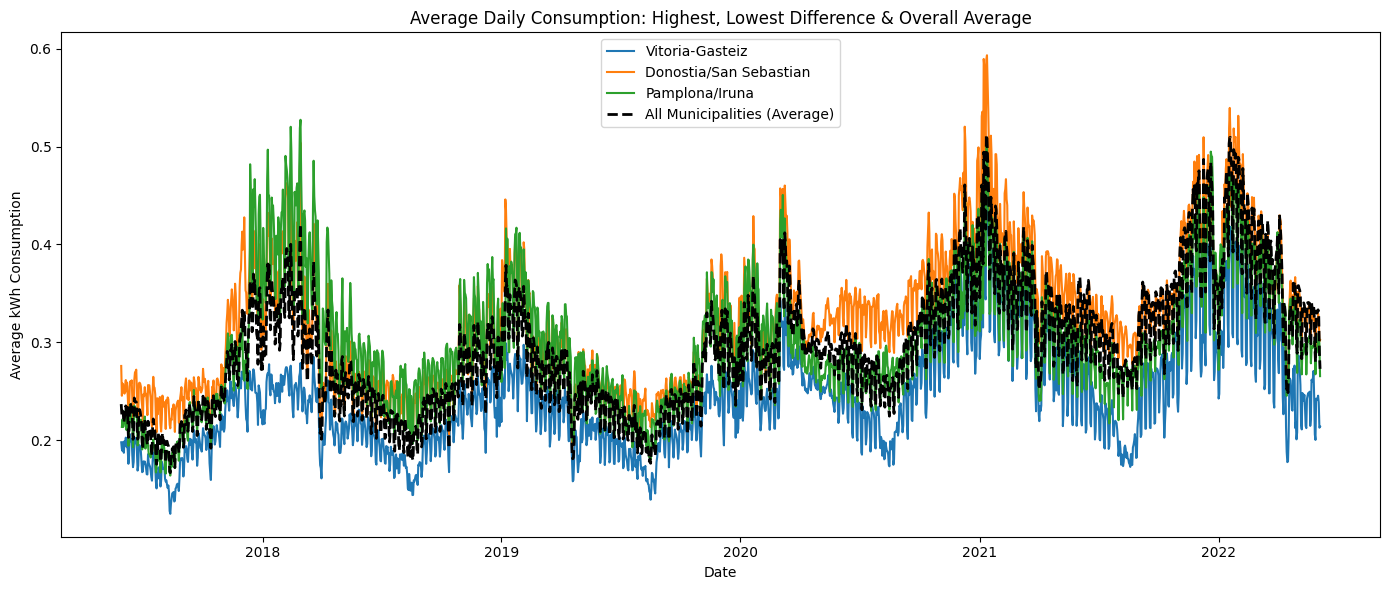

In [6]:
plt.figure(figsize=(14, 6))
for muni in allowed_municipalities:
    subset = municipality_daily[
        (municipality_daily['municipality'] == muni) &
        (municipality_daily['n_users'] > 100)
    ]
    plt.plot(subset['date'], subset['avg_kwh'], label=muni)

# Plot the overall average
plt.plot(
    daily_avg_all_municipalities['date'],
    daily_avg_all_municipalities['avg_kwh_all_municipalities'],
    color='black', linewidth=2, linestyle='--', label='All Municipalities (Average)'
)

plt.xlabel('Date')
plt.ylabel('Average kWh Consumption')
plt.title('Average Daily Consumption: Highest, Lowest Difference & Overall Average')
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
filtered_municipality_daily = municipality_daily[
    (municipality_daily['n_users'] >= 100) &
    (municipality_daily['municipality'].isin(allowed_municipalities))
]

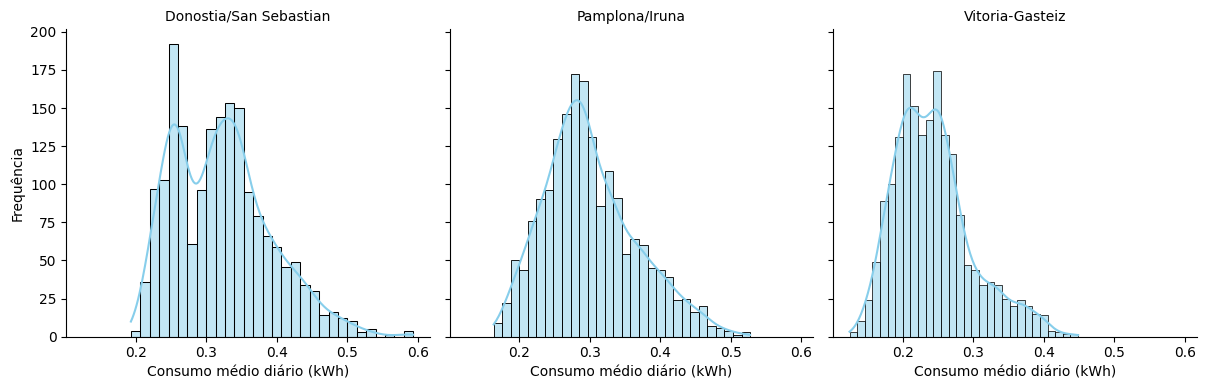

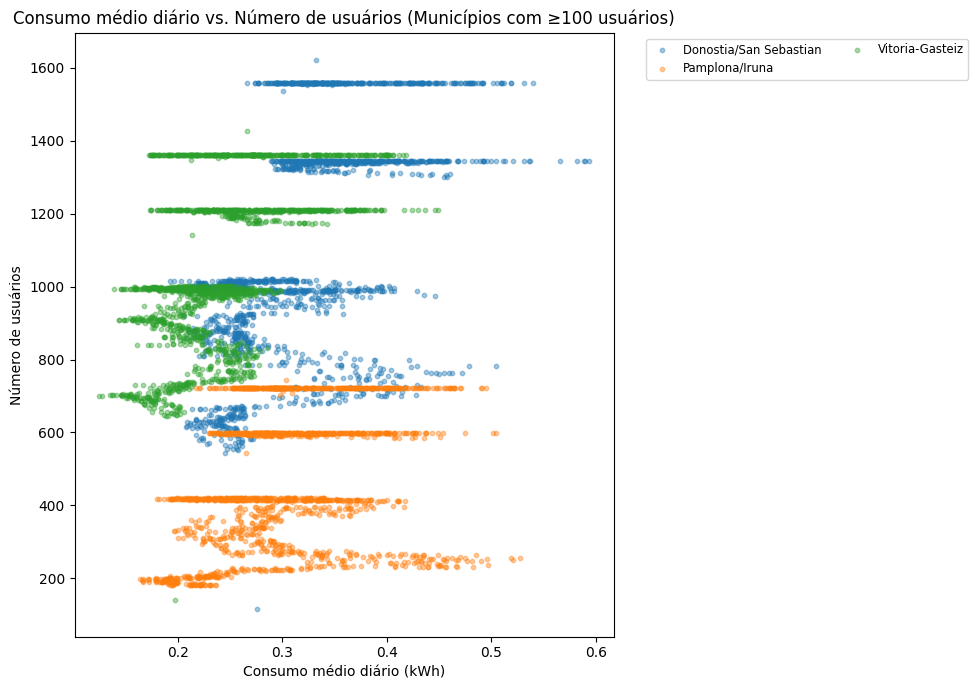

In [8]:
g = sns.FacetGrid(filtered_municipality_daily, col="municipality", col_wrap=4, sharey=True, height=4)
g.map(sns.histplot, "avg_kwh", bins=30, color='skyblue', kde=True)
g.set_axis_labels("Consumo médio diário (kWh)", "Frequência")
g.set_titles(col_template="{col_name}")
plt.tight_layout()
plt.show()

# Scatterplot: avg_kwh vs n_users for filtered municipalities
plt.figure(figsize=(10, 7))
for muni in filtered_municipality_daily['municipality'].unique():
    subset = filtered_municipality_daily[filtered_municipality_daily['municipality'] == muni]
    plt.scatter(subset['avg_kwh'], subset['n_users'], alpha=0.4, label=muni, s=10)
plt.xlabel('Consumo médio diário (kWh)')
plt.ylabel('Número de usuários')
plt.title('Consumo médio diário vs. Número de usuários (Municípios com ≥100 usuários)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', ncol=2)
plt.tight_layout()
plt.show()

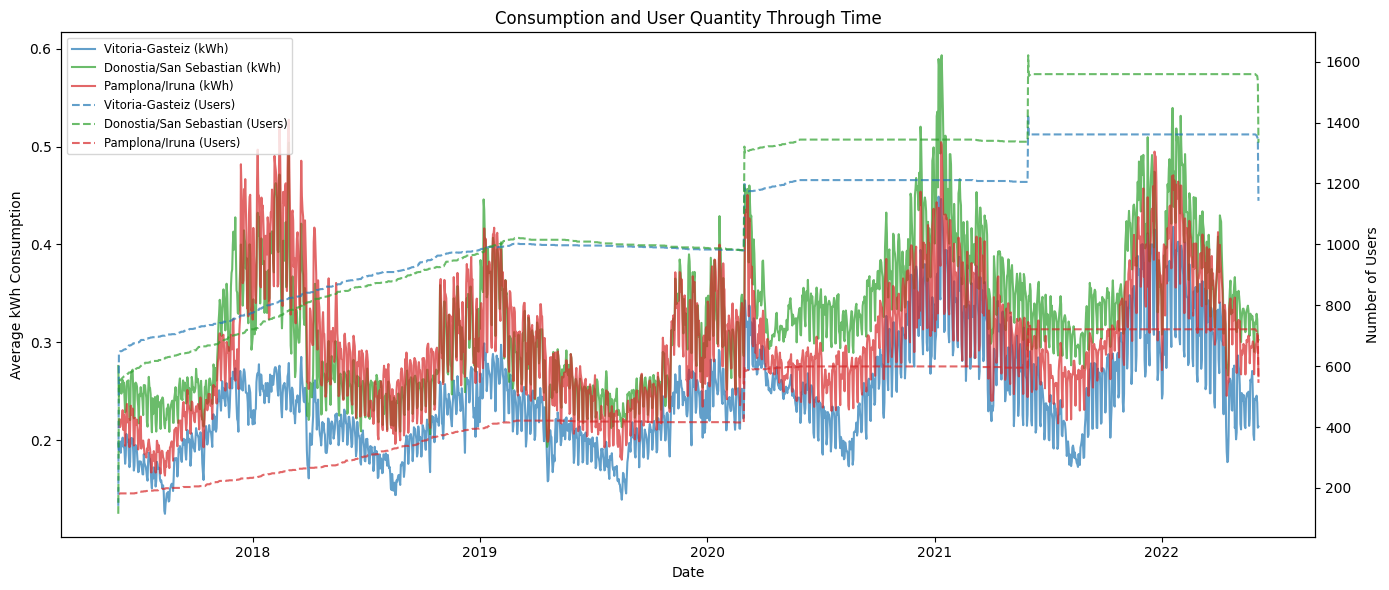

In [9]:
fig, ax1 = plt.subplots(figsize=(14, 6))

colors = ['tab:blue', 'tab:green', 'tab:red']
ax1.set_xlabel('Date')
ax1.set_ylabel('Average kWh Consumption')
for muni, color in zip(allowed_municipalities, colors):
    subset = filtered_municipality_daily[filtered_municipality_daily['municipality'] == muni]
    ax1.plot(subset['date'], subset['avg_kwh'], label=f'{muni} (kWh)', color=color, alpha=0.7)
ax1.tick_params(axis='y')

ax2 = ax1.twinx()
ax2.set_ylabel('Number of Users')
for muni, color in zip(allowed_municipalities, colors):
    subset = filtered_municipality_daily[filtered_municipality_daily['municipality'] == muni]
    ax2.plot(subset['date'], subset['n_users'], label=f'{muni} (Users)', color=color, linestyle='--', alpha=0.7)
ax2.tick_params(axis='y')

lines, labels = [], []
for ax in [ax1, ax2]:
    line, label = ax.get_legend_handles_labels()
    lines += line
    labels += label
ax1.legend(lines, labels, loc='upper left', fontsize='small')

plt.title('Consumption and User Quantity Through Time')
plt.tight_layout()
plt.show()
